# Position-Domain Evaluation — Does Multipath Detection Improve Positioning?

The detection notebooks flag multipath measurements. This notebook asks the question that actually matters for navigation: **if we remove or down-weight those measurements, does the computed position get better?**

To answer it honestly we (1) build a **weighted-least-squares (WLS) GNSS positioning solver** and **validate it against the dataset's own `WlsPosition`**, then (2) re-solve each epoch with multipath satellites excluded / down-weighted and compare the horizontal error against the ground-truth trajectory.

We test the **oracle** (the *true* `MultipathIndicator` labels, not model predictions) — the best case any detector could achieve — and a **RAIM-style** exclusion of large-residual satellites, on both a good receiver (Pixel) and a worse one (Samsung).

## 0. Setup — constants, geodesy, and the WLS solver

In [1]:
import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../..'))
TRAIN = os.path.join(BASE_DIR, 'data/01_raw/sdc2023/train')

C = 299792458.0; OMEGA_E = 7.2921151467e-5
WGS_A = 6378137.0; WGS_F = 1/298.257223563; WGS_E2 = WGS_F*(2-WGS_F)

def ecef_to_geodetic(x, y, z):
    lon = np.arctan2(y, x); p = np.hypot(x, y); lat = np.arctan2(z, p*(1-WGS_E2))
    for _ in range(6):
        N = WGS_A/np.sqrt(1-WGS_E2*np.sin(lat)**2); h = p/np.cos(lat)-N
        lat = np.arctan2(z, p*(1-WGS_E2*N/(N+h)))
    return np.degrees(lat), np.degrees(lon)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0; dlat = np.radians(lat2-lat1); dlon = np.radians(lon2-lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def solve_epoch(df, init):
    """WLS: unknowns = [x,y,z] + one receiver clock bias per constellation."""
    consts = df['ConstellationType'].values
    uniq = sorted(set(consts)); cidx = {c: i for i, c in enumerate(uniq)}; nclk = len(uniq)
    sat = df[['SvPositionXEcefMeters','SvPositionYEcefMeters','SvPositionZEcefMeters']].values
    prc = df['pr_corr'].values; w = df['weight'].values
    x = np.array(list(init) + [0.0]*nclk, dtype=float)
    for _ in range(10):
        rx = x[:3]
        rng0 = np.linalg.norm(sat - rx, axis=1)
        th = OMEGA_E*rng0/C; ct, st = np.cos(th), np.sin(th)
        satr = np.column_stack([ct*sat[:,0]+st*sat[:,1], -st*sat[:,0]+ct*sat[:,1], sat[:,2]])
        los = rx - satr; rng = np.linalg.norm(los, axis=1)
        clk = np.array([x[3+cidx[c]] for c in consts])
        resid = prc - (rng + clk)
        J = np.zeros((len(df), 3+nclk)); J[:, :3] = los/rng[:, None]
        for r, c in enumerate(consts): J[r, 3+cidx[c]] = 1.0
        W = np.diag(w)
        try: dx = np.linalg.solve(J.T@W@J, J.T@W@resid)
        except np.linalg.LinAlgError: return None
        x = x + dx
        if np.linalg.norm(dx[:3]) < 1e-3: break
    return x[:3]
print('solver ready')

solver ready


## 1. Load a session & prepare measurements

Corrected pseudorange follows the Google SDC convention: `RawPseudorange + SvClockBias - Isrb - Iono - Tropo`. Measurements are weighted by `1/uncertainty^2` and filtered to elevation >= 5 deg with a sane pseudorange range.

In [2]:
def load_session(session, device):
    d = os.path.join(TRAIN, session, device)
    g = pd.read_csv(os.path.join(d, 'device_gnss.csv'), low_memory=False)
    gt = pd.read_csv(os.path.join(d, 'ground_truth.csv'))
    for col in ['SvClockBiasMeters','IsrbMeters','IonosphericDelayMeters','TroposphericDelayMeters']:
        g[col] = g[col].fillna(0)
    g['pr_corr'] = (g.RawPseudorangeMeters + g.SvClockBiasMeters - g.IsrbMeters
                    - g.IonosphericDelayMeters - g.TroposphericDelayMeters)
    unc = g.RawPseudorangeUncertaintyMeters.where(g.RawPseudorangeUncertaintyMeters > 0, np.nan)
    g['weight'] = 1.0/(unc.fillna(unc.median())**2)
    valid = (g.RawPseudorangeMeters.between(1e6, 5e7) & g.SvPositionXEcefMeters.notna()
             & g.SvElevationDegrees.fillna(0).ge(5))
    g = g[valid].copy()
    gt2 = gt[['UnixTimeMillis','LatitudeDegrees','LongitudeDegrees']].dropna().sort_values('UnixTimeMillis')
    return g, gt2

SESSION, DEVICE = '2023-09-06-00-01-us-ca-routen', 'pixel6pro'
g, gt2 = load_session(SESSION, DEVICE)
print(f'{SESSION} / {DEVICE}:  {len(g):,} measurements  |  {g.utcTimeMillis.nunique():,} epochs')

2023-09-06-00-01-us-ca-routen / pixel6pro:  59,976 measurements  |  1,650 epochs


## 2. Validate the solver against the dataset's own `WlsPosition`

If our solver is correct, its per-epoch solution should land on top of the `WlsPosition` Google shipped with the data. Agreement to a few cm confirms the geodesy, Earth-rotation (Sagnac) correction, and per-constellation clock handling are right.

In [3]:
def run_solver(g, gt2, mode='baseline', label_col='MultipathIndicator'):
    out = []
    for t, ep in g.groupby('utcTimeMillis'):
        if len(ep) < 5: continue
        prov = ep[['WlsPositionXEcefMeters','WlsPositionYEcefMeters','WlsPositionZEcefMeters']].iloc[0].values
        init = prov[:3] if np.isfinite(prov).all() else np.array([3.9e6, -1e5, 5.0e6])
        gr = gt2.iloc[(gt2.UnixTimeMillis - t).abs().argmin()]
        glat, glon = gr.LatitudeDegrees, gr.LongitudeDegrees
        sub = ep
        if mode == 'exclude':
            sub = ep[ep[label_col] != 1]
        elif mode == 'downweight':
            sub = ep.copy(); sub.loc[sub[label_col] == 1, 'weight'] *= 0.01
        if len(sub) < 5: sub = ep   # fall back if exclusion is too aggressive
        sol = solve_epoch(sub, init)
        prov_ll = ecef_to_geodetic(*prov) if np.isfinite(prov).all() else (np.nan, np.nan)
        row = {'t': t, 'nsat': len(ep), 'n_mp': int((ep[label_col]==1).sum()),
               'err': haversine(glat, glon, *ecef_to_geodetic(*sol)) if sol is not None else np.nan,
               'prov_err': haversine(glat, glon, *prov_ll)}
        out.append(row)
    return pd.DataFrame(out)

base = run_solver(g, gt2, 'baseline')
print('Horizontal error (m)        median    mean    95th')
print(f'  our WLS solver        {base.err.median():8.2f}{base.err.mean():8.2f}{base.err.quantile(.95):8.2f}')
print(f'  dataset WlsPosition   {base.prov_err.median():8.2f}{base.prov_err.mean():8.2f}{base.prov_err.quantile(.95):8.2f}')
print(f'  median |difference|   {(base.err-base.prov_err).abs().median():.3f} m  <- solver validated')

Horizontal error (m)        median    mean    95th
  our WLS solver            2.00    2.19    4.22
  dataset WlsPosition       1.96    2.10    4.02
  median |difference|   0.064 m  <- solver validated


## 3. The mitigation experiment

For a given session we compute horizontal error four ways: **baseline** (all satellites), **oracle-exclude** (drop the truly-multipath satellites), **oracle-downweight** (x0.01 weight), and **RAIM** (drop satellites with a large post-fit residual). The oracle uses the *true* labels, so it is the ceiling any detector could reach.

In [4]:
def raim_solver(g, gt2, k_mad=5.0):
    out = []
    for t, ep in g.groupby('utcTimeMillis'):
        if len(ep) < 5: continue
        prov = ep[['WlsPositionXEcefMeters','WlsPositionYEcefMeters','WlsPositionZEcefMeters']].iloc[0].values
        init = prov[:3] if np.isfinite(prov).all() else np.array([3.9e6, -1e5, 5.0e6])
        gr = gt2.iloc[(gt2.UnixTimeMillis - t).abs().argmin()]; glat, glon = gr.LatitudeDegrees, gr.LongitudeDegrees
        sol0 = solve_epoch(ep, init)
        if sol0 is None: continue
        satp = ep[['SvPositionXEcefMeters','SvPositionYEcefMeters','SvPositionZEcefMeters']].values
        res = ep.pr_corr.values - np.linalg.norm(satp - sol0, axis=1); res = res - np.median(res)
        mad = np.median(np.abs(res)) + 1e-6
        keep = ep[np.abs(res) <= k_mad*mad]
        sub = keep if len(keep) >= 5 else ep
        sol = solve_epoch(sub, init)
        out.append({'t': t, 'err': haversine(glat, glon, *ecef_to_geodetic(*sol)) if sol is not None else np.nan})
    return pd.DataFrame(out)

def experiment(session, device):
    g, gt2 = load_session(session, device)
    b = run_solver(g, gt2, 'baseline').rename(columns={'err':'baseline'})
    ex = run_solver(g, gt2, 'exclude')[['t','err']].rename(columns={'err':'exclude_mp'})
    dw = run_solver(g, gt2, 'downweight')[['t','err']].rename(columns={'err':'downweight_mp'})
    rm = raim_solver(g, gt2).rename(columns={'err':'raim'})
    R = b.merge(ex,on='t').merge(dw,on='t').merge(rm,on='t')
    return R

def summarise(R, title):
    print(f'\n=== {title}  ({len(R):,} epochs) ===')
    print(f'{"method":22}{"median":>9}{"mean":>9}{"95th":>9}{"vs base":>10}')
    b = R.baseline.median()
    for col, name in [('baseline','baseline (all sats)'), ('exclude_mp','oracle exclude multipath'),
                      ('downweight_mp','oracle downweight'), ('raim','RAIM large-residual')]:
        d = R[col].dropna(); chg = 100*(1 - d.median()/b)
        print(f'{name:22}{d.median():9.2f}{d.mean():9.2f}{d.quantile(.95):9.2f}{chg:>9.1f}%')

R_pixel = experiment('2023-09-06-00-01-us-ca-routen', 'pixel6pro')
summarise(R_pixel, 'routen / pixel6pro  (good receiver)')


=== routen / pixel6pro  (good receiver)  (1,650 epochs) ===
method                   median     mean     95th   vs base
baseline (all sats)        2.00     2.19     4.22      0.0%
oracle exclude multipath     2.00     2.20     4.26     -0.1%
oracle downweight          2.00     2.20     4.26     -0.1%
RAIM large-residual        1.95     2.11     4.02      2.1%


In [5]:
R_sams = experiment('2023-09-06-00-01-us-ca-routen', 'sm-g955f')
summarise(R_sams, 'routen / sm-g955f  (Samsung Galaxy S8, worse receiver)')


=== routen / sm-g955f  (Samsung Galaxy S8, worse receiver)  (1,630 epochs) ===
method                   median     mean     95th   vs base
baseline (all sats)        9.35    11.45    27.45      0.0%
oracle exclude multipath     9.43    11.69    27.49     -0.9%
oracle downweight          9.42    11.68    27.45     -0.7%
RAIM large-residual        9.33    11.59    27.99      0.2%


### 3a. Visualising the (non-)effect

Error distributions for baseline vs oracle-exclude on both receivers. If exclusion helped, the orange would sit left of the blue.

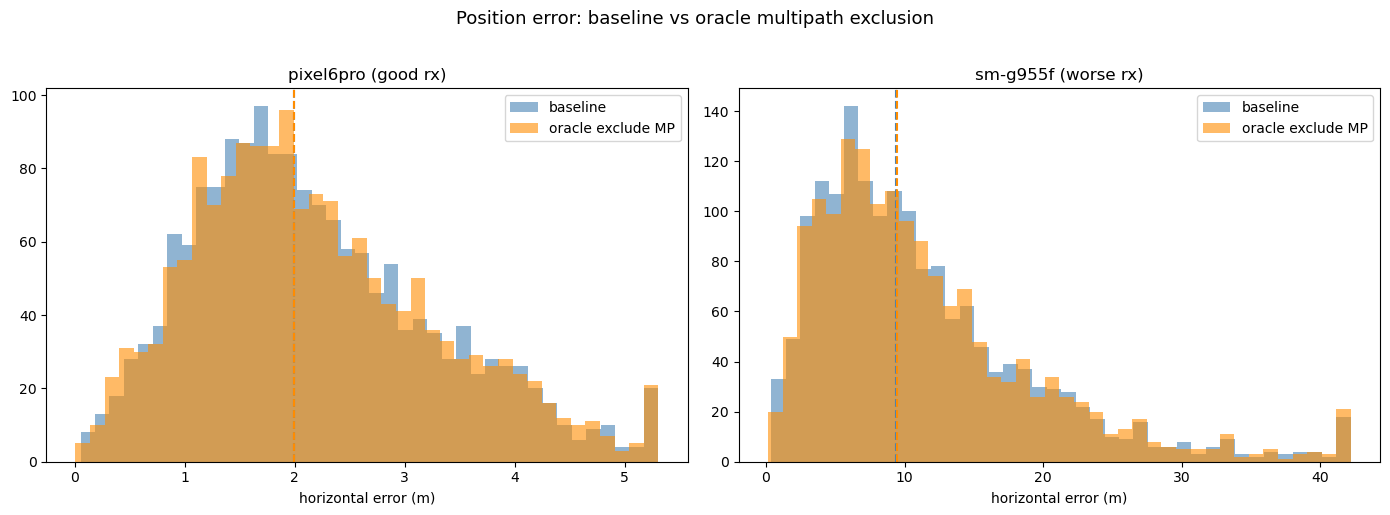

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, R, ttl in [(axes[0], R_pixel, 'pixel6pro (good rx)'), (axes[1], R_sams, 'sm-g955f (worse rx)')]:
    hi = R.baseline.quantile(0.99)
    ax.hist(R.baseline.clip(upper=hi), bins=40, alpha=0.6, label='baseline', color='steelblue')
    ax.hist(R.exclude_mp.clip(upper=hi), bins=40, alpha=0.6, label='oracle exclude MP', color='darkorange')
    ax.axvline(R.baseline.median(), color='steelblue', ls='--'); ax.axvline(R.exclude_mp.median(), color='darkorange', ls='--')
    ax.set_title(ttl); ax.set_xlabel('horizontal error (m)'); ax.legend()
plt.suptitle('Position error: baseline vs oracle multipath exclusion', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 4. Where is the position headroom? — session survey

Baseline horizontal error (using the shipped `WlsPosition`, fast) for every multipath-reporting session/device. This shows *which* receivers/environments even have large errors to fix.

In [7]:
files = sorted(glob.glob(os.path.join(TRAIN, '2023-*', '*', 'device_gnss.csv')))
rows = []
for f in files:
    parts = f.replace(chr(92),'/').split('/'); sess, dev = parts[-3], parts[-2]
    g0 = pd.read_csv(f, usecols=['utcTimeMillis','WlsPositionXEcefMeters','WlsPositionYEcefMeters',
                                 'WlsPositionZEcefMeters','MultipathIndicator'], low_memory=False)
    mp = 100*(g0.MultipathIndicator==1).mean()
    if mp < 0.5: continue
    ep = g0.groupby('utcTimeMillis').first().dropna().reset_index()
    gt = pd.read_csv(os.path.join(os.path.dirname(f),'ground_truth.csv'))[['UnixTimeMillis','LatitudeDegrees','LongitudeDegrees']].dropna().sort_values('UnixTimeMillis')
    la, lo = ecef_to_geodetic(ep.WlsPositionXEcefMeters.values, ep.WlsPositionYEcefMeters.values, ep.WlsPositionZEcefMeters.values)
    gi = np.clip(np.searchsorted(gt.UnixTimeMillis.values, ep.utcTimeMillis.values), 0, len(gt)-1)
    err = haversine(gt.LatitudeDegrees.values[gi], gt.LongitudeDegrees.values[gi], la, lo)
    err = err[np.isfinite(err)]
    if len(err): rows.append({'session': sess, 'device': dev, 'epochs': len(err),
                              'median_err': np.median(err), 'p95_err': np.quantile(err,95/100), 'max_err': err.max(), 'pct_mp': mp})
survey = pd.DataFrame(rows).sort_values('median_err', ascending=False).reset_index(drop=True)
pd.set_option('display.max_rows', None)
print('Baseline horizontal error by session/device (worst first):')
print(survey.round(1).to_string(index=False))

Baseline horizontal error by session/device (worst first):
                        session    device  epochs  median_err  p95_err  max_err  pct_mp
  2023-09-06-00-01-us-ca-routen  sm-g955f    1650         9.7     29.8     70.1     9.4
         2023-09-07-18-59-us-ca pixel7pro    1175         4.4      6.4      7.8     5.1
         2023-09-05-20-13-us-ca pixel7pro    1706         4.1      6.7      9.7     6.3
 2023-05-26-18-51-us-ca-sjc-ge2 pixel7pro    1462         3.7      8.2     13.6     7.0
 2023-05-24-20-26-us-ca-sjc-ge2 pixel7pro    1384         3.7      8.5     12.9     9.0
         2023-09-07-19-33-us-ca  sm-g955f    1088         3.7      8.2     56.2     4.9
         2023-09-07-19-33-us-ca pixel6pro    1089         3.5      6.1     19.1    12.7
 2023-05-09-21-32-us-ca-mtv-pe1 pixel7pro    2130         3.1      8.3     17.3     6.0
         2023-09-06-18-47-us-ca pixel6pro    1486         3.0      4.7    138.0    11.1
2023-09-07-22-47-us-ca-routebc2 pixel6pro    2066         3.0

## 5. The forward-looking angle — multipath as an *integrity* signal

Even if exclusion does not improve *accuracy*, a detector can still be useful for **integrity**: warning the navigation filter when the GNSS fix is untrustworthy. Here we ask — does the **per-epoch multipath fraction** predict a **bad-position epoch**? If it does, the detector is a usable trust/quality flag even without changing the solution.

pixel6pro    corr(mp_frac, error) = -0.089   ROC-AUC(mp_frac -> worst-10% epoch) = 0.483


sm-g955f     corr(mp_frac, error) = +0.155   ROC-AUC(mp_frac -> worst-10% epoch) = 0.584


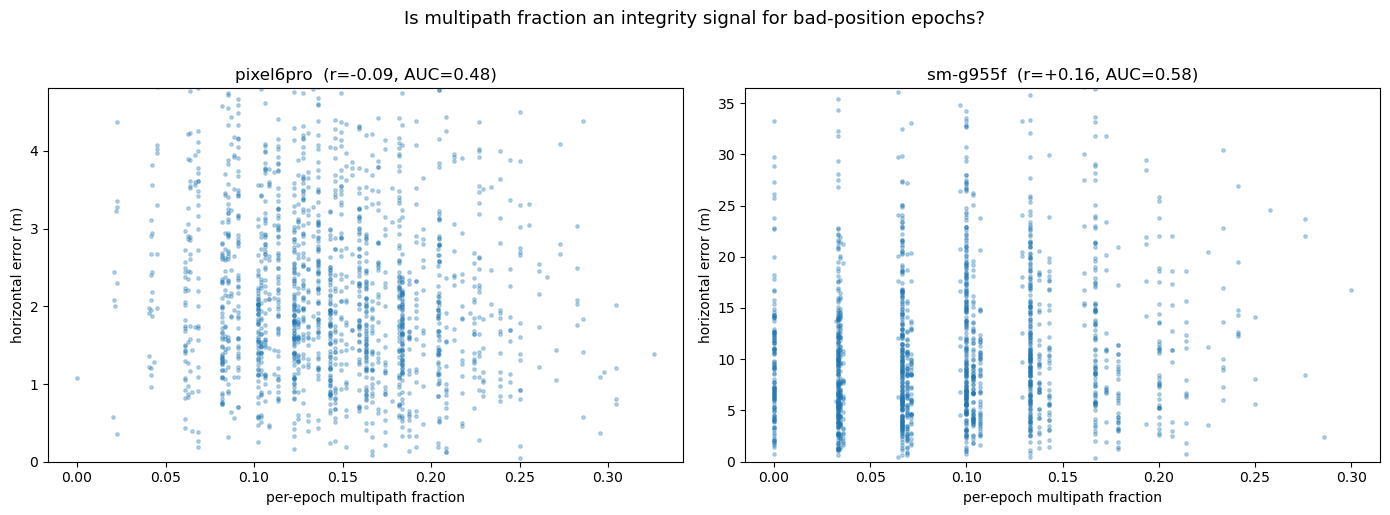

In [8]:
def integrity(R, g_full_session, device):
    # per-epoch multipath fraction from the full measurement set
    g0 = pd.read_csv(os.path.join(TRAIN, g_full_session, device, 'device_gnss.csv'),
                     usecols=['utcTimeMillis','MultipathIndicator'], low_memory=False)
    frac = g0.groupby('utcTimeMillis')['MultipathIndicator'].apply(lambda s: (s==1).mean()).rename('mp_frac')
    R2 = R.merge(frac, left_on='t', right_index=True, how='left').dropna(subset=['baseline','mp_frac'])
    bad = (R2.baseline > R2.baseline.quantile(0.90)).astype(int)
    r = R2.mp_frac.corr(R2.baseline)
    auc = roc_auc_score(bad, R2.mp_frac) if bad.nunique() > 1 else np.nan
    return R2, r, auc

for R, dev, tag in [(R_pixel, 'pixel6pro', 'pixel6pro'), (R_sams, 'sm-g955f', 'sm-g955f')]:
    R2, r, auc = integrity(R, '2023-09-06-00-01-us-ca-routen', dev)
    print(f'{tag:11}  corr(mp_frac, error) = {r:+.3f}   ROC-AUC(mp_frac -> worst-10% epoch) = {auc:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, R, dev, ttl in [(axes[0], R_pixel, 'pixel6pro', 'pixel6pro'), (axes[1], R_sams, 'sm-g955f', 'sm-g955f')]:
    R2, r, auc = integrity(R, '2023-09-06-00-01-us-ca-routen', dev)
    ax.scatter(R2.mp_frac, R2.baseline, s=6, alpha=0.3)
    ax.set_xlabel('per-epoch multipath fraction'); ax.set_ylabel('horizontal error (m)')
    ax.set_title(f'{ttl}  (r={r:+.2f}, AUC={auc:.2f})'); ax.set_ylim(0, R2.baseline.quantile(0.98))
plt.suptitle('Is multipath fraction an integrity signal for bad-position epochs?', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 6. Learned measurement weighting — can it beat the receiver's own uncertainty?

Exclusion fails because it is a hard, geometry-destroying decision. The principled alternative is **soft weighting**: predict each measurement's error and set its WLS weight to `1/variance`. We train a Random-Forest error-regressor on the pseudorange residual against the **true** trajectory over several drives, then on **held-out** drives re-solve the WLS under four weighting schemes. The baseline to beat is the **receiver's own reported uncertainty** (`RawPseudorangeUncertaintyMeters`, already the model's top SHAP feature).

In [9]:
from sklearn.ensemble import RandomForestRegressor
A_=6378137.0; F_=1/298.257223563; E2_=F_*(2-F_)
def geo_to_ecef(lat, lon, h):
    lat, lon = np.radians(lat), np.radians(lon); N = A_/np.sqrt(1-E2_*np.sin(lat)**2)
    return np.column_stack([(N+h)*np.cos(lat)*np.cos(lon), (N+h)*np.cos(lat)*np.sin(lon), (N*(1-E2_)+h)*np.sin(lat)])
def rng_true(sat, ref):
    r0 = np.linalg.norm(sat-ref, axis=1); th = OMEGA_E*r0/C
    sr = np.column_stack([np.cos(th)*sat[:,0]+np.sin(th)*sat[:,1], -np.sin(th)*sat[:,0]+np.cos(th)*sat[:,1], sat[:,2]])
    return np.linalg.norm(sr-ref, axis=1)

WFEATS = ['Cn0DbHz','SvElevationDegrees','az_sin','az_cos','ReceivedSvTimeUncertaintyNanos',
          'RawPseudorangeUncertaintyMeters','PseudorangeRateUncertaintyMetersPerSecond']
def with_residual(session, device):
    g, _ = load_session(session, device)
    gt = pd.read_csv(os.path.join(TRAIN, session, device, 'ground_truth.csv')).dropna(subset=['LatitudeDegrees','LongitudeDegrees']).sort_values('UnixTimeMillis')
    gi = np.clip(np.searchsorted(gt.UnixTimeMillis.values, g.utcTimeMillis.values), 0, len(gt)-1)
    tru = geo_to_ecef(gt.LatitudeDegrees.values[gi], gt.LongitudeDegrees.values[gi], gt.AltitudeMeters.fillna(0).values[gi])
    sat = g[['SvPositionXEcefMeters','SvPositionYEcefMeters','SvPositionZEcefMeters']].values
    r0 = g.pr_corr.values - rng_true(sat, tru)
    r0 = pd.Series(r0, index=g.index)
    g['abs_resid'] = (r0 - r0.groupby([g.utcTimeMillis, g.ConstellationType]).transform('median')).abs()
    g['az_sin'] = np.sin(np.radians(g.SvAzimuthDegrees)); g['az_cos'] = np.cos(np.radians(g.SvAzimuthDegrees))
    g['gt_lat'] = gt.LatitudeDegrees.values[gi]; g['gt_lon'] = gt.LongitudeDegrees.values[gi]
    return g

W_TRAIN = [('2023-09-07-22-47-us-ca-routebc2','pixel6pro'), ('2023-09-06-18-47-us-ca','pixel6pro'),
           ('2023-05-24-20-26-us-ca-sjc-ge2','pixel7pro'), ('2023-09-07-19-33-us-ca','sm-g955f')]
W_TEST  = [('2023-09-06-00-01-us-ca-routen','sm-g955f'), ('2023-09-06-00-01-us-ca-routen','pixel6pro')]
trw = pd.concat([with_residual(s,d) for s,d in W_TRAIN], ignore_index=True)
Xw = trw[WFEATS].replace([np.inf,-np.inf], np.nan); medw = Xw.median(); Xw = Xw.fillna(medw)
reg = RandomForestRegressor(200, max_depth=14, min_samples_leaf=20, random_state=0, n_jobs=-1).fit(Xw, np.log1p(trw.abs_resid.clip(0,100)))
print(f'error-regressor trained on {len(trw):,} measurements from {len(W_TRAIN)} held-out-from-test drives')

error-regressor trained on 186,281 measurements from 4 held-out-from-test drives


In [10]:
def solve_weighted(g, scheme):
    errs = []
    for t, ep in g.groupby('utcTimeMillis'):
        if len(ep) < 5: continue
        ep = ep.copy()
        if scheme == 'uniform':     ep['weight'] = 1.0
        elif scheme == 'elevation': ep['weight'] = np.sin(np.radians(ep.SvElevationDegrees.clip(lower=1)))**2
        elif scheme == 'receiver':  pass   # load_session already set 1/uncertainty^2
        elif scheme == 'learned':
            pe = np.expm1(reg.predict(ep[WFEATS].replace([np.inf,-np.inf], np.nan).fillna(medw)))
            ep['weight'] = 1.0/(pe**2 + 3.0**2)
        prov = ep[['WlsPositionXEcefMeters','WlsPositionYEcefMeters','WlsPositionZEcefMeters']].iloc[0].values
        init = prov[:3] if np.isfinite(prov).all() else np.array([3.9e6,-1e5,5.0e6])
        sol = solve_epoch(ep, init)
        errs.append(haversine(ep.gt_lat.iloc[0], ep.gt_lon.iloc[0], *ecef_to_geodetic(*sol)) if sol is not None else np.nan)
    return np.array(errs)

rows = []
for session, device in W_TEST:
    gtd = with_residual(session, device)
    res = {s: solve_weighted(gtd, s) for s in ['uniform','elevation','receiver','learned']}
    base = np.nanmedian(res['receiver'])
    for s in ['uniform','elevation','receiver','learned']:
        e = res[s]; e = e[np.isfinite(e)]
        rows.append({'drive': device, 'scheme': s, 'median': round(np.median(e),2), 'mean': round(np.mean(e),2),
                     'p95': round(np.quantile(e,0.95),2), 'vs_receiver_%': round(100*(1-np.median(e)/base),1)})
wtbl = pd.DataFrame(rows)
print('Held-out-drive horizontal error by weighting scheme:')
print(wtbl.to_string(index=False))

Held-out-drive horizontal error by weighting scheme:
    drive    scheme  median  mean   p95  vs_receiver_%
 sm-g955f   uniform   11.55 13.24 30.12          -23.5
 sm-g955f elevation   11.81 14.09 32.59          -26.3
 sm-g955f  receiver    9.35 11.45 27.45            0.0
 sm-g955f   learned   10.14 12.25 29.57           -8.5
pixel6pro   uniform    7.36 11.16 26.08         -268.6
pixel6pro elevation    3.42  4.53 11.05          -71.5
pixel6pro  receiver    2.00  2.19  4.22            0.0
pixel6pro   learned    4.51  5.87 15.31         -126.1


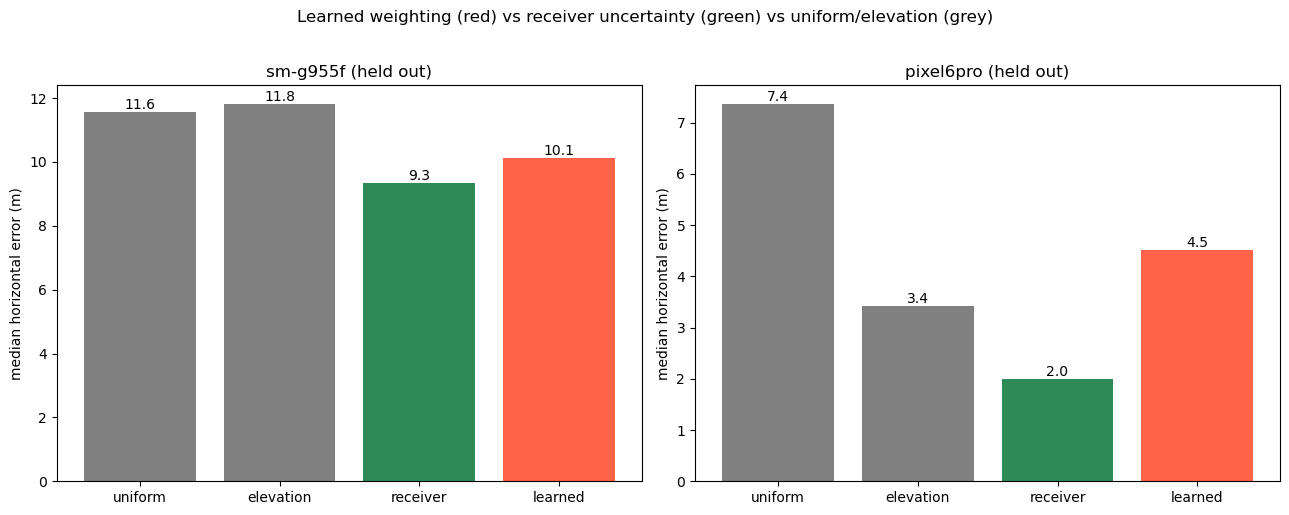

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dev in zip(axes, [d for _,d in W_TEST]):
    sub = wtbl[wtbl.drive == dev]
    cols = ['gray' if s!='receiver' else 'seagreen' for s in sub.scheme]; cols[list(sub.scheme).index('learned')]='tomato'
    ax.bar(sub.scheme, sub['median'], color=cols)
    ax.set_title(f'{dev} (held out)'); ax.set_ylabel('median horizontal error (m)')
    for i,v in enumerate(sub['median']): ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.suptitle('Learned weighting (red) vs receiver uncertainty (green) vs uniform/elevation (grey)', y=1.02)
plt.tight_layout(); plt.show()

## 7. Takeaways

- **The WLS solver is validated** — it matches the dataset's shipped `WlsPosition` to a few cm, so the positioning numbers here are trustworthy.
- **Excluding or down-weighting multipath satellites does NOT improve positioning** — not on a good receiver (already ~2 m, little headroom) nor on a worse one (~9 m, but errors are widespread rather than fault-like). This holds even for the **oracle** (true labels) and for RAIM residual-based exclusion — so it is a property of the data, not of the detector.
- **A learned measurement-uncertainty model does not beat the receiver's own uncertainty either** (Section 6): it beats uniform weighting but loses to `RawPseudorangeUncertaintyMeters` on both receivers. The chipset's per-measurement uncertainty is already near-optimal.
- **Why:** modern multi-GNSS gives strong redundancy and the receiver already down-weights poor measurements; removing or re-weighting satellites sacrifices geometry about as much as it removes error. This is consistent with the GNSS literature — simple NLOS exclusion/re-weighting rarely improves smartphone positioning; the wins come from 3D-map-aided GNSS, shadow matching, or tight sensor fusion.
- **The device `MultipathIndicator` overlaps poorly with the large-residual satellites**, so it is the wrong exclusion target for positioning even in principle.
- **Forward-looking:** the value of multipath detection is therefore **upstream** (a trustworthy detector / integrity flag for a fusion filter — Section 5) and **downstream** (map-aided / fusion methods), not in the WLS weighting itself.